In [1]:
import os
import pickle
import torch
from model import DelphiConfig, Delphi
from tqdm import tqdm
import pandas as pd
import numpy as np
import textwrap
import warnings

import seaborn as sns
import matplotlib.pyplot as plt

%config InlineBackend.figure_format='retina'

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams.update({'axes.grid': True,
                     'grid.linestyle': ':',
                     'axes.spines.bottom': False,
          'axes.spines.left': False,
          'axes.spines.right': False,
          'axes.spines.top': False})
plt.rcParams['figure.dpi']= 72
plt.rcParams['pdf.fonttype'] = 42

import pickle

In [15]:
device = 'cuda' # examples: 'cpu', 'cuda', 'cuda:0', 'cuda:1', etc.
seed = 1337

torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cuda.matmul.allow_tf32 = True # allow tf32 on matmul
torch.backends.cudnn.allow_tf32 = True # allow tf32 on cudnn

device_type = 'cuda' if 'cuda' in device else 'cpu'
dtype = getattr(torch, 'float32') 

In [16]:
# delphi_labels = pd.read_csv('delphi_labels_chapters_colours_icd_with_hla4d.csv')
# labels = pd.read_csv("data/ukb_real_data_4digit/labels.csv", header=None, sep="\t")

In [17]:
from utils import get_batch, get_p2i, DelphiData

In [18]:
delphi_data = DelphiData(data_dir="data/ukb_real_5_folds_4digit/", delphi_labels="delphi_labels_chapters_colours_icd_with_hla4d.csv", device="gpu", labels="data/ukb_real_5_folds_4digit/labels.csv", val_fold=1)

In [11]:
SHAP_PKL = "shap_values_merged_dc74321948ca409fafd57c80e476b2d8.pkl"

with open(SHAP_PKL, 'rb') as f:
    shap_pkl = pickle.load(f)
    
all_tokens = shap_pkl['tokens']
all_values = shap_pkl['values']

In [12]:
df_shap = pd.DataFrame(all_values)
df_shap['token'] = all_tokens.astype('int')
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

df_shap = pd.DataFrame(all_values)
df_shap['token'] = all_tokens.astype('int')

In [13]:
token_count_dict = df_shap['token'].value_counts().sort_index().to_dict()

# N_min = 5

# columns_more_N = [c for c in df_shap.columns if c == 1269+359 or (c in token_count_dict and token_count_dict[c] >= N_min)]
# columns_more_N = [c for c in df_shap.columns if c == 1269+359]
# df_shap_agg = df_shap[df_shap['token'].apply(lambda x: token_count_dict[x] > N_min)].groupby('token').mean()
df_shap_agg = df_shap.groupby('token').mean()

In [19]:
df_shap_agg

,0,1,2,3,4,5,6,7,8,9,...,1619,1620,1621,1622,1623,1624,1625,1626,1627,1628
token,,,,,,,,,,,,,,,,,,,,,
1,0.007098,0.005156,0.011951,0.007427,0.005030,0.001155,0.005463,0.002391,-0.000099,0.002681,...,-0.004660,-0.000294,-0.001108,-0.000095,-0.004037,-0.006332,-0.001350,-0.002309,0.011852,-0.001451
2,-0.092235,0.250040,-0.307888,-0.359506,-0.139879,-0.201517,-0.092140,-0.159515,-0.181903,-0.126831,...,-0.199104,-0.089335,-0.106840,-0.150911,-0.161235,-0.231518,-0.078309,-0.096158,0.055505,-0.217769
3,-0.075948,0.205906,-0.232429,-0.093602,-0.131764,0.084231,-0.028911,-0.062778,0.146030,-0.029477,...,0.203628,-0.136706,0.017682,0.008821,0.138761,0.026251,-0.112408,0.016299,-0.671813,0.203345
5,0.259123,-0.757418,0.994869,0.871475,0.439997,0.186090,0.193146,0.327116,0.130011,0.435512,...,0.324135,0.314450,0.112572,0.191201,0.149209,0.370634,0.188761,0.161274,0.671989,0.182334
6,0.283361,-0.561574,0.687307,0.738251,0.402240,0.306970,0.255740,0.274668,0.266525,0.319781,...,0.010294,0.258791,-0.028427,0.099952,-0.039633,0.229766,0.317521,0.156799,0.812830,-0.047257
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1624,0.735238,-0.030088,0.317322,0.743922,0.620808,0.780993,0.464280,0.492183,0.733186,0.509386,...,-0.024754,-0.119285,0.192697,0.103297,0.482977,1.417462,0.698505,0.343903,0.350530,1.056364
1625,0.635062,-0.010768,0.612818,0.886585,0.574686,0.790264,0.532207,0.508391,0.661194,0.495104,...,0.101276,-0.057242,-0.026084,0.275696,1.072274,1.676553,1.320571,0.393257,0.381435,0.569999
1626,0.296750,0.006196,0.470265,0.299029,0.278038,0.137421,0.317952,0.083061,0.135005,0.283907,...,0.059270,0.165566,0.343388,0.215727,0.192994,0.311951,0.243627,0.610911,0.257985,0.405688


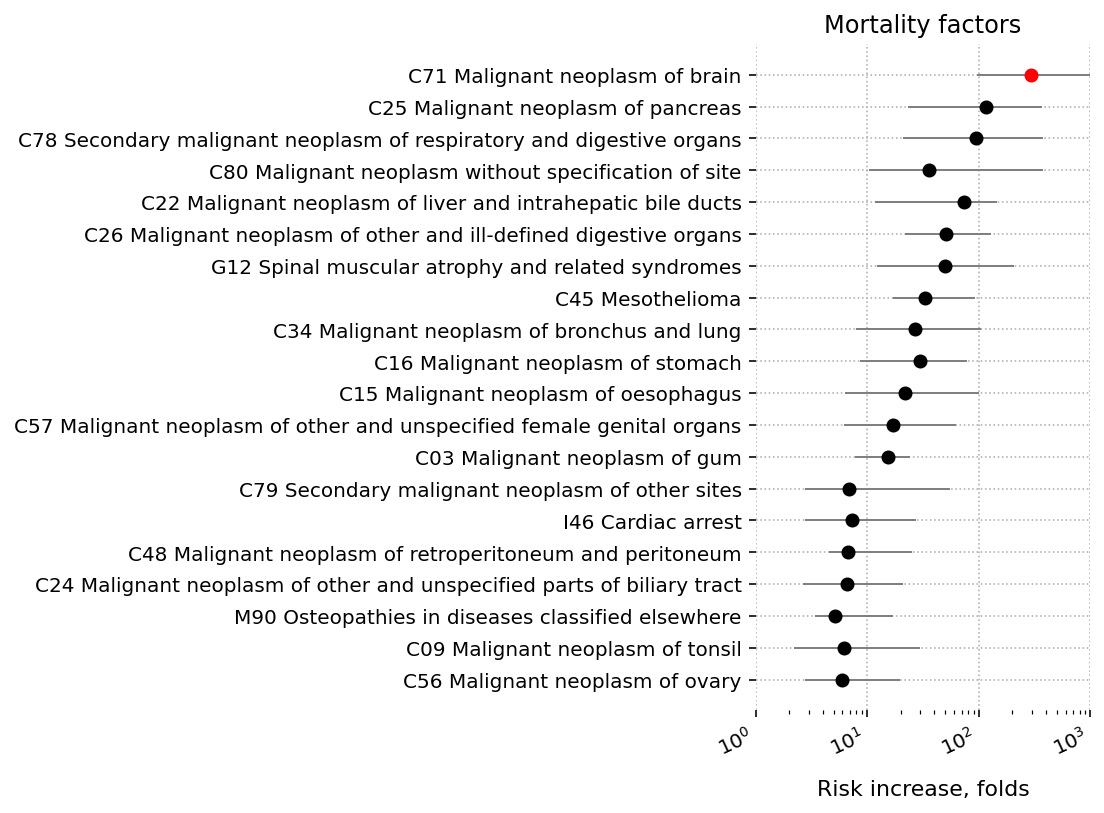

In [11]:
import matplotlib.pyplot as plt
import numpy as np

N = 1269 + 359
n_first = 20
positive = True

# Determine the most probable tokens and values based on the condition
if positive:
    most_probable_tokens = df_shap_agg[N].nlargest(n_first).index[::-1]
    most_probable_values = df_shap_agg[N].nlargest(n_first).values[::-1]
else:
    most_probable_tokens = df_shap_agg[N].nsmallest(n_first).index[::-1]
    most_probable_values = df_shap_agg[N].nsmallest(n_first).values[::-1]

# Prepare the data
df_shap_selected_melted = df_shap[df_shap['token'].isin(most_probable_tokens)][[N, 'token']].reset_index(drop=True).melt(id_vars=['token'])
df_shap_selected_melted['token'] = df_shap_selected_melted['token'].map(id_to_token)
df_shap_selected_melted['value'] = np.exp(df_shap_selected_melted['value'])

# Create a figure and axis
plt.figure(figsize=(3, 6), facecolor='w')
ax = plt.gca()

# Map most_probable_tokens to their string representations
token_strings = [id_to_token[token] for token in most_probable_tokens]

# Plot median and quartiles for each token
for i, token in enumerate(token_strings):
    data = df_shap_selected_melted[df_shap_selected_melted['token'] == token]['value']
    median = np.median(data)
    quartiles = np.percentile(data, [25, 75])
    
    # Plot median
    if i == len(token_strings) - 1:
        ax.plot(median, i, 'o', color='red', zorder=3)
    else:
        ax.plot(median, i, 'o', color='black', zorder=3)
    
    # Plot quartiles
    ax.hlines(i, quartiles[0], quartiles[1], color='gray', linestyles='solid', linewidth=1)

# Set title and labels
positive_text = "" if positive else "not "
title_text = f'Mortality factors'
plt.title(title_text)
plt.yticks(range(len(token_strings)), token_strings)

# Adjust x-ticks orientation
plt.xticks(rotation=25, ha='right')
plt.xscale('log')
plt.xlim(1, 1000)
plt.xlabel('Risk increase, folds', size=11, labelpad=10)

# Show the plot
plt.show()

In [20]:
import ipywidgets as widgets
from ipywidgets import interact, fixed

In [21]:
df_shap_agg.index

Index([   1,    2,    3,    5,    6,    7,    8,    9,   10,   11,
       ...
       1619, 1620, 1621, 1622, 1623, 1624, 1625, 1626, 1627, 1628],
      dtype='int64', name='token', length=1539)

In [22]:
df_shap_agg

,0,1,2,3,4,5,6,7,8,9,...,1619,1620,1621,1622,1623,1624,1625,1626,1627,1628
token,,,,,,,,,,,,,,,,,,,,,
1,0.007098,0.005156,0.011951,0.007427,0.005030,0.001155,0.005463,0.002391,-0.000099,0.002681,...,-0.004660,-0.000294,-0.001108,-0.000095,-0.004037,-0.006332,-0.001350,-0.002309,0.011852,-0.001451
2,-0.092235,0.250040,-0.307888,-0.359506,-0.139879,-0.201517,-0.092140,-0.159515,-0.181903,-0.126831,...,-0.199104,-0.089335,-0.106840,-0.150911,-0.161235,-0.231518,-0.078309,-0.096158,0.055505,-0.217769
3,-0.075948,0.205906,-0.232429,-0.093602,-0.131764,0.084231,-0.028911,-0.062778,0.146030,-0.029477,...,0.203628,-0.136706,0.017682,0.008821,0.138761,0.026251,-0.112408,0.016299,-0.671813,0.203345
5,0.259123,-0.757418,0.994869,0.871475,0.439997,0.186090,0.193146,0.327116,0.130011,0.435512,...,0.324135,0.314450,0.112572,0.191201,0.149209,0.370634,0.188761,0.161274,0.671989,0.182334
6,0.283361,-0.561574,0.687307,0.738251,0.402240,0.306970,0.255740,0.274668,0.266525,0.319781,...,0.010294,0.258791,-0.028427,0.099952,-0.039633,0.229766,0.317521,0.156799,0.812830,-0.047257
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1624,0.735238,-0.030088,0.317322,0.743922,0.620808,0.780993,0.464280,0.492183,0.733186,0.509386,...,-0.024754,-0.119285,0.192697,0.103297,0.482977,1.417462,0.698505,0.343903,0.350530,1.056364
1625,0.635062,-0.010768,0.612818,0.886585,0.574686,0.790264,0.532207,0.508391,0.661194,0.495104,...,0.101276,-0.057242,-0.026084,0.275696,1.072274,1.676553,1.320571,0.393257,0.381435,0.569999
1626,0.296750,0.006196,0.470265,0.299029,0.278038,0.137421,0.317952,0.083061,0.135005,0.283907,...,0.059270,0.165566,0.343388,0.215727,0.192994,0.311951,0.243627,0.610911,0.257985,0.405688


In [29]:
labels[0][labels[0].str.startswith("E14")]

577    E14 Unspecified diabetes mellitus
Name: 0, dtype: object

0                                                HLA-B*15:18
1                                                HLA-B*15:18
2                                                HLA-B*15:18
3                                                HLA-B*15:18
4                                                HLA-B*15:18
                                 ...                        
1010795    H36 Retinal disorders in diseases classified e...
1010796    H36 Retinal disorders in diseases classified e...
1010797    H36 Retinal disorders in diseases classified e...
1010798    H36 Retinal disorders in diseases classified e...
1010799    H36 Retinal disorders in diseases classified e...
Name: variable, Length: 1010800, dtype: object


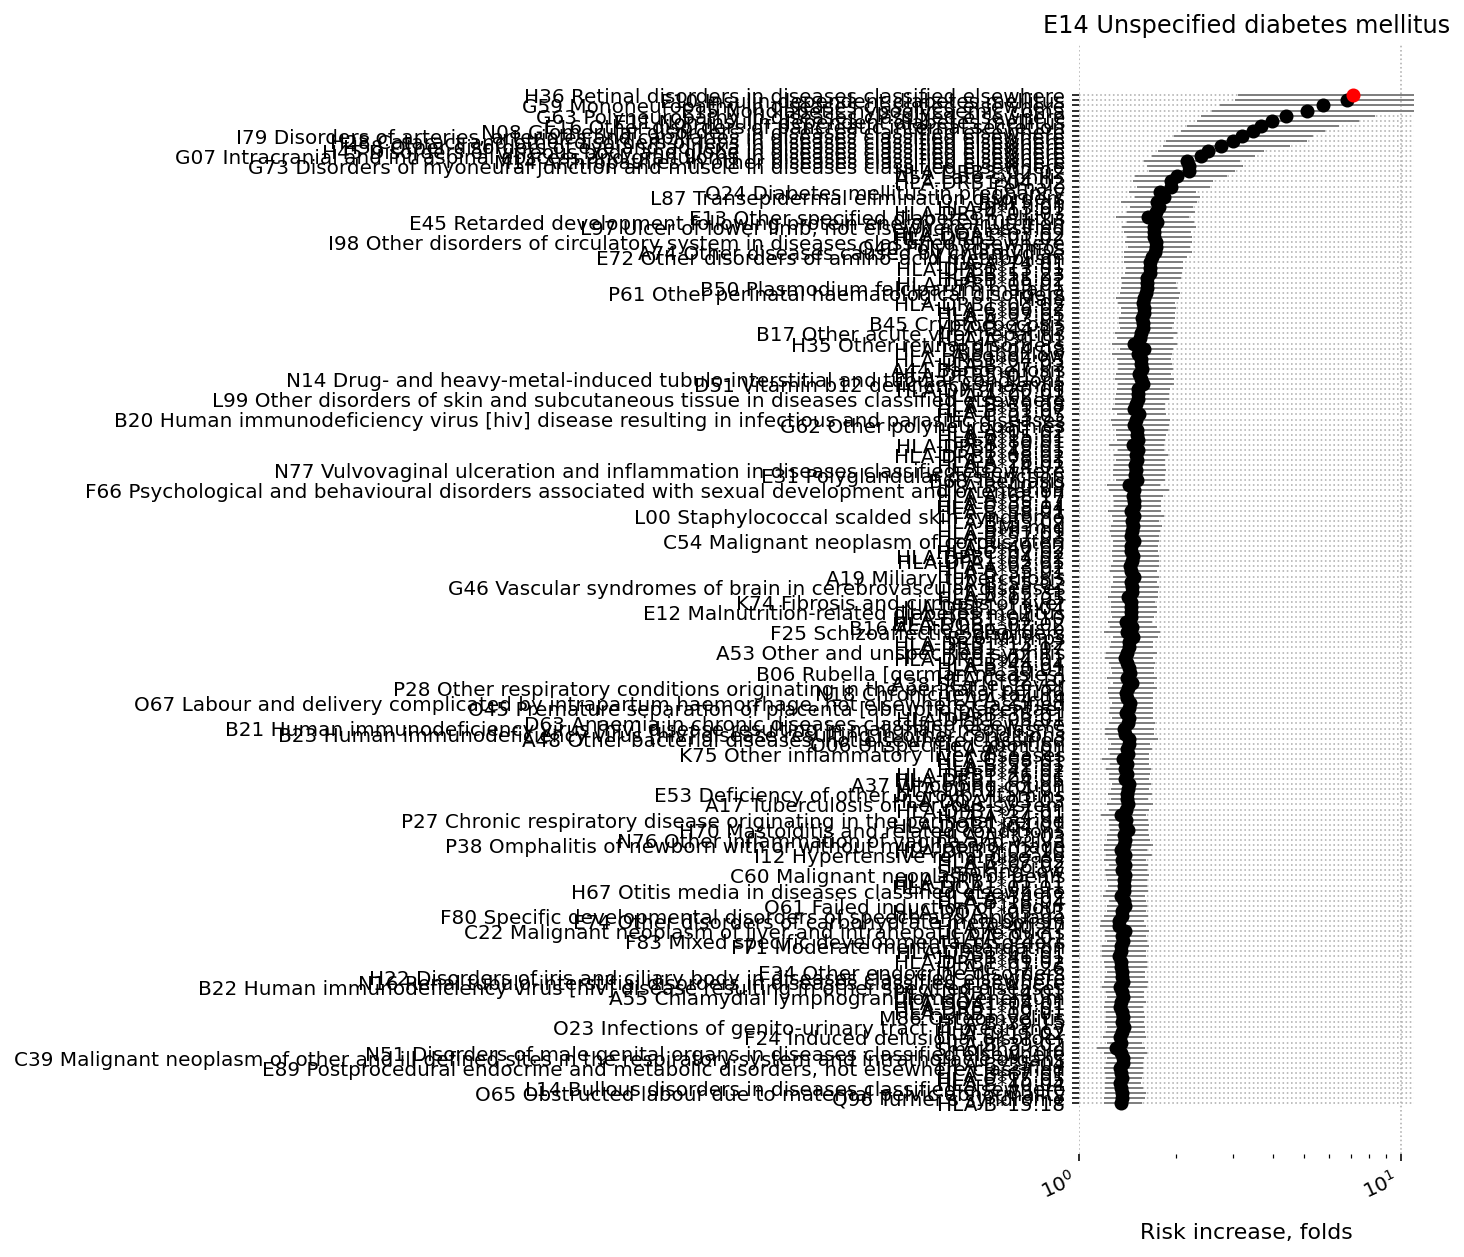

In [41]:
# N = labels.index[labels[0] == disease][0]
N = 577

# print(disease)
n_first = 200
positive = True

# Determine the most probable tokens and values based on the condition
if positive:
    most_probable_tokens = df_shap_agg.loc[N].argsort()[::-1][:n_first][::-1]
else:
    most_probable_tokens = df_shap_agg.loc[N].argsort()[:n_first][::-1]

# print(most_probable_tokens)
# Prepare the data
df_shap_selected_melted = df_shap[df_shap['token'] == N][[*most_probable_tokens, 'token']].reset_index(drop=True).melt(id_vars=['token'])
df_shap_selected_melted['token'] = df_shap_selected_melted['token'].map(id_to_token)
df_shap_selected_melted['variable'] = df_shap_selected_melted['variable'].map(id_to_token)

df_shap_selected_melted['value'] = np.exp(df_shap_selected_melted['value'])

# df_shap_selected_melted = df_shap_selected_melted[df_shap_selected_melted.variable.str.contains("HLA")]
print(df_shap_selected_melted.variable.)
    
# Create a figure and axis
plt.figure(figsize=(3, 10), facecolor='w')
ax = plt.gca()

# Map most_probable_tokens to their string representations
token_strings = [id_to_token[token] for token in most_probable_tokens]

# Plot median and quartiles for each token
for i, token in enumerate(token_strings):
    data = df_shap_selected_melted[df_shap_selected_melted['variable'] == token]['value']
    median = np.median(data)
    quartiles = np.percentile(data, [25, 75])
    
    # Plot median
    ax.plot(median, i, 'o', color='red' if (i==len(token_strings)-1) else 'black', zorder=3)
    
    # Plot quartiles
    ax.hlines(i, quartiles[0], quartiles[1], color='gray', linestyles='solid', linewidth=1)

# Set title and labels
title_text = labels.loc[N][0]
plt.title(title_text)
plt.yticks(range(len(token_strings)), token_strings)

# Adjust x-ticks orientation
plt.xticks(rotation=25, ha='right')
plt.xscale('log')
plt.xlim(1, 11)
plt.xlabel('Risk increase, folds', size=11, labelpad=10)

# Show the plot
plt.show()

In [23]:
@interact
def show_shap_values(disease=widgets.SelectionSlider(options=[ x for x in labels.loc[df_shap_agg.index][0].to_list() if "HLA" in x])):
  
    N = labels.index[labels[0] == disease][0]

    print(disease)

    n_first = 40
    positive = True
    
    # Determine the most probable tokens and values based on the condition
    if positive:
        most_probable_tokens = df_shap_agg.loc[N].argsort()[::-1][:n_first][::-1]
    else:
        most_probable_tokens = df_shap_agg.loc[N].argsort()[:n_first][::-1]
    
    print(most_probable_tokens)
    # Prepare the data
    df_shap_selected_melted = df_shap[df_shap['token'] == N][[*most_probable_tokens, 'token']].reset_index(drop=True).melt(id_vars=['token'])
    df_shap_selected_melted['token'] = df_shap_selected_melted['token'].map(id_to_token)
    df_shap_selected_melted['variable'] = df_shap_selected_melted['variable'].map(id_to_token)
    
    df_shap_selected_melted['value'] = np.exp(df_shap_selected_melted['value'])
    # print(df_shap_selected_melted)
        
    # Create a figure and axis
    plt.figure(figsize=(3, 10), facecolor='w')
    ax = plt.gca()
    
    # Map most_probable_tokens to their string representations
    token_strings = [id_to_token[token] for token in most_probable_tokens]
    
    # Plot median and quartiles for each token
    for i, token in enumerate(token_strings):
        data = df_shap_selected_melted[df_shap_selected_melted['variable'] == token]['value']
        median = np.median(data)
        quartiles = np.percentile(data, [25, 75])
        
        # Plot median
        ax.plot(median, i, 'o', color='red' if (i==len(token_strings)-1) else 'black', zorder=3)
        
        # Plot quartiles
        ax.hlines(i, quartiles[0], quartiles[1], color='gray', linestyles='solid', linewidth=1)
    
    # Set title and labels
    title_text = labels.loc[N][0]
    plt.title(title_text)
    plt.yticks(range(len(token_strings)), token_strings)
    
    # Adjust x-ticks orientation
    plt.xticks(rotation=25, ha='right')
    plt.xscale('log')
    plt.xlim(1, 11)
    plt.xlabel('Risk increase, folds', size=11, labelpad=10)
    
    # Show the plot
    plt.show()

interactive(children=(SelectionSlider(description='disease', options=('HLA-A*01:02', 'HLA-A*01:03', 'HLA-A*02:…